# Scenario

A pharmaceutical company is conducting clinical trials to evaluate the effectiveness of three antiretroviral drug combinations for treating HIV-positive patients. Due to the ethical and cost constraints of clinical trials, it is critical to identify the most effective treatment regimen using the least number of patients. Each treatment (or “arm”) can lead to different outcomes depending on patient responses. The effectiveness of each treatment is evaluated using a reward function derived from the improvement in patients’ immune system markers and survival status.



# Problem Definition

You are provided with a clinical dataset where each record corresponds to a patient, including the treatment they received and the resulting health outcomes. Your task is to simulate a clinical trial environment using various MAB strategies to sequentially recommend treatments and observe outcomes. The objective is to maximize the overall success rate across trials by identifying and favouring the most effective treatment.



# Dataset

You will be provided a dataset containing the following fields:

* ***Age (age)***: Patient's age in years at baseline.
* ***Weight (wtkg)***: Continuous feature representing weight in kilograms at baseline.
* ***Gender (gender)***: Binary indicator of gender (0 = Female, 1 = Male).
* ***CD4 Counts (cd40, cd420)***: Integer values representing CD4 counts at baseline and 20+/-5 weeks.
* ***Treatment Indicator (trt)***: Categorical feature indicating the type of treatment received (0 = ZDV only, 1 = ZDV + ddI, 2 = ZDV + Zal, 3 = ddI only).
* ***Censoring Indicator (label)***: Binary indicator (1 = failure, 0 = censoring) denoting patient status.


***Link for accessing dataset:***
https://drive.google.com/file/d/1LYfIrJ4VEEGeyOsSt_qoLk7FaAv5Jfx-/view?usp=sharing


# Environment Setup

***Arms (Actions):*** The treatment types (trt)
* Arm 0: ZDV only
* Arm 1: ZDV + ddI
* Arm 2: ZDV + Zal
* Arm 3: ddI only


**Reward Function:**

Reward `r` is defined as:

`r = 1, if (label == 0) and (cd420 > cd40)`

`r = 0, otherwise`


  
This reward represents a successful treatment outcome as an increase in CD4 count and survival.

**Assumptions:**

*Number of Iterations:* Run the simulation for at least 1000 trials (iterations), with the option to extend the number of trials depending on the convergence behavior or observed reward trends. In each iteration, simulate one patient trial using one of the bandit policies.


# Requirements and Deliverables:
Implement the Multi-Arm Bandit Problem for the given above scenario for all the below mentioned policy methods.

### Initialize constants

In [ ]:
import pandas as pd
import numpy as np
import random
import math
import matplotlib.pyplot as plt

csv_path = "C:/Users/User/OneDrive - wilp.bits-pilani.ac.in/Desktop/Suku_BITS/SEM - 2/DRL/Clinical_Trial.csv" # path of data set
iterations = 1000 # number of simulation steps to analyse the performance of policies
epsilon = 0.1 # Exploration rate

# Load Dataset

In [ ]:
# Loading the dataset
df = pd.read_csv(csv_path)

# Displaying first few rows
print(" First 5 rows of the dataset:")
print(df.head(), "\n")

# Dataset shape
print(f"Total records: {df.shape[0]}, Total features: {df.shape[1]}")

# Data types and non-null values
print("\n Dataset Info:")
df_summary = pd.DataFrame({
    "Non-Null Count": df.notnull().sum(),
    "Dtype": df.dtypes
})
print(df_summary)

# Basic statistics (numerical columns)
print("\n Summary Statistics:")
print(df.describe())

# Checking for missing values
print("\n Missing Values in Each Column:")
print(df.isnull().sum())


 First 5 rows of the dataset:
   age     wtkg  gender  cd40  cd420  trt  label
0   48  89.8128       0   422    477    2      0
1   61  49.4424       0   162    218    3      1
2   45  88.4520       1   326    274    3      0
3   47  85.2768       1   287    394    3      0
4   43  66.6792       1   504    353    0      0 

Total records: 2139, Total features: 7

 Dataset Info:
        Non-Null Count    Dtype
age               2139    int64
wtkg              2139  float64
gender            2139    int64
cd40              2139    int64
cd420             2139    int64
trt               2139    int64
label             2139    int64

 Summary Statistics:
               age         wtkg       gender         cd40        cd420  \
count  2139.000000  2139.000000  2139.000000  2139.000000  2139.000000   
mean     35.248247    75.125311     0.827957   350.501169   371.307153   
std       8.709026    13.263164     0.377506   118.573863   144.634909   
min      12.000000    31.000000     0.000000 

# Design a Clinical Trial Environment

In [ ]:
# Code for environment setup along with reward function
#-----write your code below this line---------

class ClinicalTrialEnvironment:
    def __init__(self, dataframe):
        self.df = dataframe.copy()  # Keep original df safe
        self.n_arms = self.df['trt'].nunique()  # Count distinct treatment arms
        self._prepare_rewards()  # Compute reward column

    def _prepare_rewards(self):
        self.df['reward'] = self.df.apply(
            lambda row: int((row['label'] == 0) and (row['cd420'] > row['cd40'])),
            axis=1
        )
        self.df.reset_index(drop=True, inplace=True)

    def sample_patient(self, arm):
        arm_patients = self.df[self.df['trt'] == arm]
        if arm_patients.empty:
            raise ValueError(f"No patients found for treatment arm {arm}")
        return arm_patients.sample(1).iloc[0]

    def get_num_arms(self):
        return self.n_arms

    def reset(self):
        self.df = self.df.copy()
        self._prepare_rewards()

# Using Random Policy
Implement a random policy for treatment selection and print each iteration. (Mandatory)

In [ ]:
#  run the environment with an agent that is guided by a random policy
#-----write your code below this line---------
# Create the environment
env = ClinicalTrialEnvironment(df)

# Set number of iterations

n_arms = env.get_num_arms()

# Tracking reward and selections
random_rewards = []
random_selections = np.zeros(n_arms)

# Running simulation
print(f"\nRunning Random Policy : ")
for i in range(iterations):
    chosen_arm = random.randint(0, n_arms - 1)  # Select an arm randomly
    patient = env.sample_patient(chosen_arm)
    reward = patient['reward']

    random_rewards.append(reward)
    random_selections[chosen_arm] += 1

    print(f"Iteration {i+1}: Arm {chosen_arm} selected → Reward: {reward}")


Running Random Policy : 
Iteration 1: Arm 1 selected → Reward: 0.0
Iteration 2: Arm 1 selected → Reward: 1.0
Iteration 3: Arm 1 selected → Reward: 0.0
Iteration 4: Arm 0 selected → Reward: 0.0
Iteration 5: Arm 2 selected → Reward: 1.0
Iteration 6: Arm 3 selected → Reward: 0.0
Iteration 7: Arm 3 selected → Reward: 0.0
Iteration 8: Arm 0 selected → Reward: 1.0
Iteration 9: Arm 0 selected → Reward: 0.0
Iteration 10: Arm 1 selected → Reward: 1.0
Iteration 11: Arm 2 selected → Reward: 1.0
Iteration 12: Arm 1 selected → Reward: 0.0
Iteration 13: Arm 3 selected → Reward: 0.0
Iteration 14: Arm 2 selected → Reward: 1.0
Iteration 15: Arm 0 selected → Reward: 0.0
Iteration 16: Arm 1 selected → Reward: 0.0
Iteration 17: Arm 3 selected → Reward: 0.0
Iteration 18: Arm 0 selected → Reward: 0.0
Iteration 19: Arm 3 selected → Reward: 1.0
Iteration 20: Arm 0 selected → Reward: 0.0
Iteration 21: Arm 3 selected → Reward: 1.0
Iteration 22: Arm 2 selected → Reward: 0.0
Iteration 23: Arm 3 selected → Reward

Iteration 261: Arm 2 selected → Reward: 0.0
Iteration 262: Arm 1 selected → Reward: 0.0
Iteration 263: Arm 2 selected → Reward: 1.0
Iteration 264: Arm 2 selected → Reward: 0.0
Iteration 265: Arm 0 selected → Reward: 0.0
Iteration 266: Arm 3 selected → Reward: 0.0
Iteration 267: Arm 1 selected → Reward: 1.0
Iteration 268: Arm 3 selected → Reward: 1.0
Iteration 269: Arm 1 selected → Reward: 1.0
Iteration 270: Arm 0 selected → Reward: 0.0
Iteration 271: Arm 1 selected → Reward: 0.0
Iteration 272: Arm 3 selected → Reward: 0.0
Iteration 273: Arm 2 selected → Reward: 0.0
Iteration 274: Arm 1 selected → Reward: 0.0
Iteration 275: Arm 1 selected → Reward: 0.0
Iteration 276: Arm 0 selected → Reward: 0.0
Iteration 277: Arm 3 selected → Reward: 0.0
Iteration 278: Arm 0 selected → Reward: 0.0
Iteration 279: Arm 1 selected → Reward: 1.0
Iteration 280: Arm 2 selected → Reward: 1.0
Iteration 281: Arm 1 selected → Reward: 0.0
Iteration 282: Arm 2 selected → Reward: 1.0
Iteration 283: Arm 1 selected → 

Iteration 511: Arm 1 selected → Reward: 0.0
Iteration 512: Arm 2 selected → Reward: 0.0
Iteration 513: Arm 2 selected → Reward: 1.0
Iteration 514: Arm 1 selected → Reward: 1.0
Iteration 515: Arm 0 selected → Reward: 0.0
Iteration 516: Arm 3 selected → Reward: 0.0
Iteration 517: Arm 0 selected → Reward: 0.0
Iteration 518: Arm 0 selected → Reward: 0.0
Iteration 519: Arm 0 selected → Reward: 1.0
Iteration 520: Arm 2 selected → Reward: 0.0
Iteration 521: Arm 2 selected → Reward: 0.0
Iteration 522: Arm 3 selected → Reward: 1.0
Iteration 523: Arm 2 selected → Reward: 1.0
Iteration 524: Arm 2 selected → Reward: 1.0
Iteration 525: Arm 2 selected → Reward: 1.0
Iteration 526: Arm 2 selected → Reward: 0.0
Iteration 527: Arm 1 selected → Reward: 1.0
Iteration 528: Arm 0 selected → Reward: 0.0
Iteration 529: Arm 2 selected → Reward: 1.0
Iteration 530: Arm 2 selected → Reward: 0.0
Iteration 531: Arm 3 selected → Reward: 1.0
Iteration 532: Arm 3 selected → Reward: 1.0
Iteration 533: Arm 3 selected → 

Iteration 779: Arm 2 selected → Reward: 1.0
Iteration 780: Arm 2 selected → Reward: 0.0
Iteration 781: Arm 1 selected → Reward: 1.0
Iteration 782: Arm 2 selected → Reward: 0.0
Iteration 783: Arm 0 selected → Reward: 0.0
Iteration 784: Arm 2 selected → Reward: 1.0
Iteration 785: Arm 3 selected → Reward: 0.0
Iteration 786: Arm 1 selected → Reward: 1.0
Iteration 787: Arm 0 selected → Reward: 0.0
Iteration 788: Arm 1 selected → Reward: 1.0
Iteration 789: Arm 2 selected → Reward: 1.0
Iteration 790: Arm 3 selected → Reward: 0.0
Iteration 791: Arm 0 selected → Reward: 0.0
Iteration 792: Arm 0 selected → Reward: 0.0
Iteration 793: Arm 3 selected → Reward: 1.0
Iteration 794: Arm 2 selected → Reward: 1.0
Iteration 795: Arm 3 selected → Reward: 0.0
Iteration 796: Arm 2 selected → Reward: 0.0
Iteration 797: Arm 1 selected → Reward: 0.0
Iteration 798: Arm 0 selected → Reward: 0.0
Iteration 799: Arm 3 selected → Reward: 1.0
Iteration 800: Arm 2 selected → Reward: 0.0
Iteration 801: Arm 2 selected → 

Iteration 984: Arm 0 selected → Reward: 0.0
Iteration 985: Arm 1 selected → Reward: 1.0
Iteration 986: Arm 2 selected → Reward: 0.0
Iteration 987: Arm 3 selected → Reward: 1.0
Iteration 988: Arm 1 selected → Reward: 0.0
Iteration 989: Arm 2 selected → Reward: 1.0
Iteration 990: Arm 3 selected → Reward: 1.0
Iteration 991: Arm 2 selected → Reward: 0.0
Iteration 992: Arm 0 selected → Reward: 1.0
Iteration 993: Arm 0 selected → Reward: 1.0
Iteration 994: Arm 1 selected → Reward: 0.0
Iteration 995: Arm 2 selected → Reward: 0.0
Iteration 996: Arm 1 selected → Reward: 1.0
Iteration 997: Arm 0 selected → Reward: 0.0
Iteration 998: Arm 2 selected → Reward: 1.0
Iteration 999: Arm 2 selected → Reward: 0.0
Iteration 1000: Arm 0 selected → Reward: 0.0


# Using Greedy Policy
Implement the Greedy policy that always selects the treatment with the highest average reward and print each iteration. (Mandatory)

In [ ]:
#  run the environment with an agent that is guided by a greedy policy
#-----write your code below this line---------
# Reinitialize environment
env = ClinicalTrialEnvironment(df)

# Initialize tracking variables
n_arms = env.get_num_arms()


arm_counts = np.zeros(n_arms)
arm_avg_rewards = np.zeros(n_arms)

greedy_rewards = []
greedy_selections = np.zeros(n_arms)

# Running greedy agent
print(f"\nRunning Greedy Policy : ")
for i in range(iterations):
    # Checking for unexplored arms
    unexplored_arms = np.where(arm_counts == 0)[0]

    if len(unexplored_arms) > 0:
        chosen_arm = np.random.choice(unexplored_arms)
    else:
        chosen_arm = np.argmax(arm_avg_rewards)

    #Sampling patient and get reward
    patient = env.sample_patient(chosen_arm)
    reward = patient['reward']

    #Updating running average
    arm_counts[chosen_arm] += 1
    arm_avg_rewards[chosen_arm] += (reward - arm_avg_rewards[chosen_arm]) / arm_counts[chosen_arm]

    #Storing results
    greedy_rewards.append(reward)
    greedy_selections[chosen_arm] += 1


    print(f"Iteration {i+1}: Arm {chosen_arm} selected → Reward: {reward}")


Running Greedy Policy : 
Iteration 1: Arm 1 selected → Reward: 0.0
Iteration 2: Arm 2 selected → Reward: 0.0
Iteration 3: Arm 0 selected → Reward: 0.0
Iteration 4: Arm 3 selected → Reward: 1.0
Iteration 5: Arm 3 selected → Reward: 1.0
Iteration 6: Arm 3 selected → Reward: 1.0
Iteration 7: Arm 3 selected → Reward: 1.0
Iteration 8: Arm 3 selected → Reward: 0.0
Iteration 9: Arm 3 selected → Reward: 0.0
Iteration 10: Arm 3 selected → Reward: 1.0
Iteration 11: Arm 3 selected → Reward: 0.0
Iteration 12: Arm 3 selected → Reward: 1.0
Iteration 13: Arm 3 selected → Reward: 1.0
Iteration 14: Arm 3 selected → Reward: 0.0
Iteration 15: Arm 3 selected → Reward: 1.0
Iteration 16: Arm 3 selected → Reward: 0.0
Iteration 17: Arm 3 selected → Reward: 1.0
Iteration 18: Arm 3 selected → Reward: 0.0
Iteration 19: Arm 3 selected → Reward: 0.0
Iteration 20: Arm 3 selected → Reward: 0.0
Iteration 21: Arm 3 selected → Reward: 0.0
Iteration 22: Arm 3 selected → Reward: 1.0
Iteration 23: Arm 3 selected → Reward

Iteration 198: Arm 3 selected → Reward: 0.0
Iteration 199: Arm 3 selected → Reward: 0.0
Iteration 200: Arm 3 selected → Reward: 1.0
Iteration 201: Arm 3 selected → Reward: 1.0
Iteration 202: Arm 3 selected → Reward: 1.0
Iteration 203: Arm 3 selected → Reward: 0.0
Iteration 204: Arm 3 selected → Reward: 0.0
Iteration 205: Arm 3 selected → Reward: 1.0
Iteration 206: Arm 3 selected → Reward: 0.0
Iteration 207: Arm 3 selected → Reward: 0.0
Iteration 208: Arm 3 selected → Reward: 0.0
Iteration 209: Arm 3 selected → Reward: 1.0
Iteration 210: Arm 3 selected → Reward: 1.0
Iteration 211: Arm 3 selected → Reward: 0.0
Iteration 212: Arm 3 selected → Reward: 0.0
Iteration 213: Arm 3 selected → Reward: 1.0
Iteration 214: Arm 3 selected → Reward: 1.0
Iteration 215: Arm 3 selected → Reward: 0.0
Iteration 216: Arm 3 selected → Reward: 0.0
Iteration 217: Arm 3 selected → Reward: 1.0
Iteration 218: Arm 3 selected → Reward: 1.0
Iteration 219: Arm 3 selected → Reward: 1.0
Iteration 220: Arm 3 selected → 

Iteration 439: Arm 3 selected → Reward: 1.0
Iteration 440: Arm 3 selected → Reward: 0.0
Iteration 441: Arm 3 selected → Reward: 1.0
Iteration 442: Arm 3 selected → Reward: 0.0
Iteration 443: Arm 3 selected → Reward: 0.0
Iteration 444: Arm 3 selected → Reward: 0.0
Iteration 445: Arm 3 selected → Reward: 1.0
Iteration 446: Arm 3 selected → Reward: 1.0
Iteration 447: Arm 3 selected → Reward: 0.0
Iteration 448: Arm 3 selected → Reward: 0.0
Iteration 449: Arm 3 selected → Reward: 1.0
Iteration 450: Arm 3 selected → Reward: 1.0
Iteration 451: Arm 3 selected → Reward: 1.0
Iteration 452: Arm 3 selected → Reward: 1.0
Iteration 453: Arm 3 selected → Reward: 0.0
Iteration 454: Arm 3 selected → Reward: 0.0
Iteration 455: Arm 3 selected → Reward: 1.0
Iteration 456: Arm 3 selected → Reward: 1.0
Iteration 457: Arm 3 selected → Reward: 0.0
Iteration 458: Arm 3 selected → Reward: 0.0
Iteration 459: Arm 3 selected → Reward: 1.0
Iteration 460: Arm 3 selected → Reward: 0.0
Iteration 461: Arm 3 selected → 

Iteration 720: Arm 3 selected → Reward: 0.0
Iteration 721: Arm 3 selected → Reward: 1.0
Iteration 722: Arm 3 selected → Reward: 1.0
Iteration 723: Arm 3 selected → Reward: 0.0
Iteration 724: Arm 3 selected → Reward: 0.0
Iteration 725: Arm 3 selected → Reward: 0.0
Iteration 726: Arm 3 selected → Reward: 1.0
Iteration 727: Arm 3 selected → Reward: 0.0
Iteration 728: Arm 3 selected → Reward: 0.0
Iteration 729: Arm 3 selected → Reward: 1.0
Iteration 730: Arm 3 selected → Reward: 0.0
Iteration 731: Arm 3 selected → Reward: 0.0
Iteration 732: Arm 3 selected → Reward: 0.0
Iteration 733: Arm 3 selected → Reward: 1.0
Iteration 734: Arm 3 selected → Reward: 1.0
Iteration 735: Arm 3 selected → Reward: 0.0
Iteration 736: Arm 3 selected → Reward: 0.0
Iteration 737: Arm 3 selected → Reward: 0.0
Iteration 738: Arm 3 selected → Reward: 1.0
Iteration 739: Arm 3 selected → Reward: 0.0
Iteration 740: Arm 3 selected → Reward: 0.0
Iteration 741: Arm 3 selected → Reward: 0.0
Iteration 742: Arm 3 selected → 

# Using Epsilon-Greedy Policy
Implement the ε-Greedy policy with ε = 0.1, 0.2, 0.5.

In [ ]:
def epsilon_greedy_policy(env, epsilon, iterations=1000):
    eps_greedy_rewards = []
    eps_greedy_selections = []

    n_arms = env.get_num_arms()
    counts = np.zeros(n_arms)
    avg_rewards = np.zeros(n_arms)

    env.reset()
    for i in range(iterations):
        if np.random.rand() < epsilon:
            chosen_arm = np.random.randint(n_arms)  # Explore
        else:
            unexplored = np.where(counts == 0)[0]
            if len(unexplored) > 0:
                chosen_arm = np.random.choice(unexplored)
            else:
                chosen_arm = np.argmax(avg_rewards)  # Exploit


        patient = env.sample_patient(chosen_arm)
        reward = patient['reward']

        counts[chosen_arm] += 1
        avg_rewards[chosen_arm] += (reward - avg_rewards[chosen_arm]) / counts[chosen_arm]

        eps_greedy_rewards.append(reward)
        eps_greedy_selections.append(chosen_arm)

        print(f"Iteration {i+1}: Arm {chosen_arm} selected → Reward: {reward}")

    return eps_greedy_selections, eps_greedy_rewards


# Running epsilon-greedy policy simulations
env = ClinicalTrialEnvironment(df)
epsilons = [0.1, 0.2, 0.5]
results = {}

for eps in epsilons:
    print(f"\nRunning ε-Greedy Policy with ε = {eps}")
    selections, rewards = epsilon_greedy_policy(env, epsilon=eps)
    results[eps] = (selections, rewards)



Running ε-Greedy Policy with ε = 0.1
Iteration 1: Arm 1 selected → Reward: 0.0
Iteration 2: Arm 3 selected → Reward: 1.0
Iteration 3: Arm 2 selected → Reward: 1.0
Iteration 4: Arm 0 selected → Reward: 1.0
Iteration 5: Arm 0 selected → Reward: 1.0
Iteration 6: Arm 0 selected → Reward: 1.0
Iteration 7: Arm 0 selected → Reward: 1.0
Iteration 8: Arm 0 selected → Reward: 1.0
Iteration 9: Arm 2 selected → Reward: 0.0
Iteration 10: Arm 0 selected → Reward: 0.0
Iteration 11: Arm 3 selected → Reward: 0.0
Iteration 12: Arm 0 selected → Reward: 0.0
Iteration 13: Arm 0 selected → Reward: 0.0
Iteration 14: Arm 0 selected → Reward: 0.0
Iteration 15: Arm 0 selected → Reward: 0.0
Iteration 16: Arm 2 selected → Reward: 0.0
Iteration 17: Arm 0 selected → Reward: 0.0
Iteration 18: Arm 3 selected → Reward: 1.0
Iteration 19: Arm 3 selected → Reward: 0.0
Iteration 20: Arm 3 selected → Reward: 0.0
Iteration 21: Arm 0 selected → Reward: 0.0
Iteration 22: Arm 0 selected → Reward: 0.0
Iteration 23: Arm 3 selec

Iteration 251: Arm 1 selected → Reward: 0.0
Iteration 252: Arm 1 selected → Reward: 0.0
Iteration 253: Arm 1 selected → Reward: 1.0
Iteration 254: Arm 2 selected → Reward: 1.0
Iteration 255: Arm 2 selected → Reward: 0.0
Iteration 256: Arm 1 selected → Reward: 0.0
Iteration 257: Arm 1 selected → Reward: 1.0
Iteration 258: Arm 1 selected → Reward: 1.0
Iteration 259: Arm 1 selected → Reward: 1.0
Iteration 260: Arm 1 selected → Reward: 0.0
Iteration 261: Arm 1 selected → Reward: 0.0
Iteration 262: Arm 1 selected → Reward: 0.0
Iteration 263: Arm 1 selected → Reward: 1.0
Iteration 264: Arm 1 selected → Reward: 1.0
Iteration 265: Arm 1 selected → Reward: 1.0
Iteration 266: Arm 0 selected → Reward: 0.0
Iteration 267: Arm 1 selected → Reward: 0.0
Iteration 268: Arm 1 selected → Reward: 0.0
Iteration 269: Arm 1 selected → Reward: 0.0
Iteration 270: Arm 1 selected → Reward: 0.0
Iteration 271: Arm 1 selected → Reward: 0.0
Iteration 272: Arm 1 selected → Reward: 1.0
Iteration 273: Arm 1 selected → 

Iteration 537: Arm 1 selected → Reward: 1.0
Iteration 538: Arm 1 selected → Reward: 1.0
Iteration 539: Arm 1 selected → Reward: 1.0
Iteration 540: Arm 1 selected → Reward: 1.0
Iteration 541: Arm 1 selected → Reward: 0.0
Iteration 542: Arm 1 selected → Reward: 0.0
Iteration 543: Arm 1 selected → Reward: 1.0
Iteration 544: Arm 1 selected → Reward: 1.0
Iteration 545: Arm 1 selected → Reward: 0.0
Iteration 546: Arm 1 selected → Reward: 0.0
Iteration 547: Arm 1 selected → Reward: 1.0
Iteration 548: Arm 1 selected → Reward: 0.0
Iteration 549: Arm 1 selected → Reward: 0.0
Iteration 550: Arm 2 selected → Reward: 1.0
Iteration 551: Arm 3 selected → Reward: 0.0
Iteration 552: Arm 2 selected → Reward: 1.0
Iteration 553: Arm 3 selected → Reward: 0.0
Iteration 554: Arm 2 selected → Reward: 1.0
Iteration 555: Arm 2 selected → Reward: 0.0
Iteration 556: Arm 2 selected → Reward: 0.0
Iteration 557: Arm 2 selected → Reward: 1.0
Iteration 558: Arm 2 selected → Reward: 1.0
Iteration 559: Arm 1 selected → 

Iteration 804: Arm 1 selected → Reward: 0.0
Iteration 805: Arm 1 selected → Reward: 0.0
Iteration 806: Arm 1 selected → Reward: 0.0
Iteration 807: Arm 1 selected → Reward: 1.0
Iteration 808: Arm 1 selected → Reward: 0.0
Iteration 809: Arm 1 selected → Reward: 1.0
Iteration 810: Arm 1 selected → Reward: 1.0
Iteration 811: Arm 3 selected → Reward: 1.0
Iteration 812: Arm 1 selected → Reward: 1.0
Iteration 813: Arm 1 selected → Reward: 0.0
Iteration 814: Arm 1 selected → Reward: 1.0
Iteration 815: Arm 1 selected → Reward: 0.0
Iteration 816: Arm 1 selected → Reward: 0.0
Iteration 817: Arm 1 selected → Reward: 0.0
Iteration 818: Arm 1 selected → Reward: 1.0
Iteration 819: Arm 1 selected → Reward: 1.0
Iteration 820: Arm 3 selected → Reward: 1.0
Iteration 821: Arm 1 selected → Reward: 0.0
Iteration 822: Arm 1 selected → Reward: 1.0
Iteration 823: Arm 1 selected → Reward: 0.0
Iteration 824: Arm 1 selected → Reward: 0.0
Iteration 825: Arm 1 selected → Reward: 0.0
Iteration 826: Arm 1 selected → 

Iteration 55: Arm 2 selected → Reward: 0.0
Iteration 56: Arm 3 selected → Reward: 0.0
Iteration 57: Arm 3 selected → Reward: 0.0
Iteration 58: Arm 3 selected → Reward: 0.0
Iteration 59: Arm 3 selected → Reward: 1.0
Iteration 60: Arm 3 selected → Reward: 0.0
Iteration 61: Arm 3 selected → Reward: 1.0
Iteration 62: Arm 1 selected → Reward: 0.0
Iteration 63: Arm 1 selected → Reward: 1.0
Iteration 64: Arm 3 selected → Reward: 0.0
Iteration 65: Arm 3 selected → Reward: 0.0
Iteration 66: Arm 3 selected → Reward: 1.0
Iteration 67: Arm 3 selected → Reward: 1.0
Iteration 68: Arm 3 selected → Reward: 0.0
Iteration 69: Arm 1 selected → Reward: 1.0
Iteration 70: Arm 3 selected → Reward: 0.0
Iteration 71: Arm 3 selected → Reward: 0.0
Iteration 72: Arm 3 selected → Reward: 0.0
Iteration 73: Arm 0 selected → Reward: 0.0
Iteration 74: Arm 3 selected → Reward: 1.0
Iteration 75: Arm 3 selected → Reward: 0.0
Iteration 76: Arm 3 selected → Reward: 1.0
Iteration 77: Arm 3 selected → Reward: 1.0
Iteration 7

...

Iteration 579: Arm 1 selected → Reward: 0.0
Iteration 580: Arm 1 selected → Reward: 1.0
Iteration 581: Arm 1 selected → Reward: 0.0
Iteration 582: Arm 0 selected → Reward: 0.0
Iteration 583: Arm 1 selected → Reward: 1.0
Iteration 584: Arm 1 selected → Reward: 1.0
Iteration 585: Arm 1 selected → Reward: 1.0
Iteration 586: Arm 1 selected → Reward: 1.0
Iteration 587: Arm 1 selected → Reward: 1.0
Iteration 588: Arm 1 selected → Reward: 1.0
Iteration 589: Arm 1 selected → Reward: 1.0
Iteration 590: Arm 2 selected → Reward: 0.0
Iteration 591: Arm 1 selected → Reward: 1.0
Iteration 592: Arm 1 selected → Reward: 1.0
Iteration 593: Arm 1 selected → Reward: 1.0
Iteration 594: Arm 1 selected → Reward: 0.0
Iteration 595: Arm 1 selected → Reward: 0.0
Iteration 596: Arm 1 selected → Reward: 1.0
Iteration 597: Arm 1 selected → Reward: 0.0
Iteration 598: Arm 1 selected → Reward: 0.0
Iteration 599: Arm 1 selected → Reward: 1.0
Iteration 600: Arm 1 selected → Reward: 0.0
Iteration 601: Arm 1 selected → 

Iteration 877: Arm 1 selected → Reward: 0.0
Iteration 878: Arm 1 selected → Reward: 0.0
Iteration 879: Arm 1 selected → Reward: 1.0
Iteration 880: Arm 1 selected → Reward: 0.0
Iteration 881: Arm 1 selected → Reward: 1.0
Iteration 882: Arm 2 selected → Reward: 0.0
Iteration 883: Arm 1 selected → Reward: 1.0
Iteration 884: Arm 1 selected → Reward: 0.0
Iteration 885: Arm 3 selected → Reward: 0.0
Iteration 886: Arm 1 selected → Reward: 0.0
Iteration 887: Arm 1 selected → Reward: 0.0
Iteration 888: Arm 2 selected → Reward: 0.0
Iteration 889: Arm 1 selected → Reward: 0.0
Iteration 890: Arm 1 selected → Reward: 1.0
Iteration 891: Arm 1 selected → Reward: 0.0
Iteration 892: Arm 1 selected → Reward: 0.0
Iteration 893: Arm 1 selected → Reward: 0.0
Iteration 894: Arm 1 selected → Reward: 0.0
Iteration 895: Arm 1 selected → Reward: 1.0
Iteration 896: Arm 1 selected → Reward: 0.0
Iteration 897: Arm 1 selected → Reward: 0.0
Iteration 898: Arm 1 selected → Reward: 1.0
Iteration 899: Arm 1 selected → 

Iteration 142: Arm 1 selected → Reward: 1.0
Iteration 143: Arm 1 selected → Reward: 1.0
Iteration 144: Arm 1 selected → Reward: 1.0
Iteration 145: Arm 0 selected → Reward: 1.0
Iteration 146: Arm 3 selected → Reward: 1.0
Iteration 147: Arm 1 selected → Reward: 1.0
Iteration 148: Arm 1 selected → Reward: 0.0
Iteration 149: Arm 2 selected → Reward: 0.0
Iteration 150: Arm 1 selected → Reward: 0.0
Iteration 151: Arm 2 selected → Reward: 0.0
Iteration 152: Arm 1 selected → Reward: 0.0
Iteration 153: Arm 3 selected → Reward: 1.0
Iteration 154: Arm 1 selected → Reward: 0.0
Iteration 155: Arm 2 selected → Reward: 0.0
Iteration 156: Arm 1 selected → Reward: 1.0
Iteration 157: Arm 1 selected → Reward: 0.0
Iteration 158: Arm 2 selected → Reward: 0.0
Iteration 159: Arm 1 selected → Reward: 1.0
Iteration 160: Arm 1 selected → Reward: 1.0
Iteration 161: Arm 1 selected → Reward: 0.0
Iteration 162: Arm 1 selected → Reward: 0.0
Iteration 163: Arm 1 selected → Reward: 1.0
Iteration 164: Arm 1 selected → 

Iteration 440: Arm 1 selected → Reward: 0.0
Iteration 441: Arm 1 selected → Reward: 0.0
Iteration 442: Arm 1 selected → Reward: 0.0
Iteration 443: Arm 1 selected → Reward: 0.0
Iteration 444: Arm 1 selected → Reward: 1.0
Iteration 445: Arm 1 selected → Reward: 0.0
Iteration 446: Arm 2 selected → Reward: 1.0
Iteration 447: Arm 1 selected → Reward: 0.0
Iteration 448: Arm 1 selected → Reward: 0.0
Iteration 449: Arm 1 selected → Reward: 0.0
Iteration 450: Arm 3 selected → Reward: 0.0
Iteration 451: Arm 2 selected → Reward: 0.0
Iteration 452: Arm 2 selected → Reward: 0.0
Iteration 453: Arm 1 selected → Reward: 1.0
Iteration 454: Arm 1 selected → Reward: 1.0
Iteration 455: Arm 2 selected → Reward: 0.0
Iteration 456: Arm 1 selected → Reward: 0.0
Iteration 457: Arm 1 selected → Reward: 0.0
Iteration 458: Arm 1 selected → Reward: 1.0
Iteration 459: Arm 1 selected → Reward: 1.0
Iteration 460: Arm 1 selected → Reward: 1.0
Iteration 461: Arm 1 selected → Reward: 1.0
Iteration 462: Arm 0 selected → 

Iteration 758: Arm 0 selected → Reward: 0.0
Iteration 759: Arm 1 selected → Reward: 0.0
Iteration 760: Arm 3 selected → Reward: 0.0
Iteration 761: Arm 1 selected → Reward: 1.0
Iteration 762: Arm 3 selected → Reward: 0.0
Iteration 763: Arm 0 selected → Reward: 1.0
Iteration 764: Arm 1 selected → Reward: 1.0
Iteration 765: Arm 3 selected → Reward: 1.0
Iteration 766: Arm 0 selected → Reward: 1.0
Iteration 767: Arm 0 selected → Reward: 0.0
Iteration 768: Arm 1 selected → Reward: 0.0
Iteration 769: Arm 3 selected → Reward: 1.0
Iteration 770: Arm 1 selected → Reward: 1.0
Iteration 771: Arm 2 selected → Reward: 1.0
Iteration 772: Arm 1 selected → Reward: 1.0
Iteration 773: Arm 3 selected → Reward: 1.0
Iteration 774: Arm 3 selected → Reward: 0.0
Iteration 775: Arm 1 selected → Reward: 1.0
Iteration 776: Arm 1 selected → Reward: 1.0
Iteration 777: Arm 3 selected → Reward: 1.0
Iteration 778: Arm 1 selected → Reward: 1.0
Iteration 779: Arm 2 selected → Reward: 0.0
Iteration 780: Arm 1 selected → 

Report iteration-wise selections and rewards. Determine which ε yields the best result. (Mandatory)

In [ ]:
# Evaluating total rewards for each epsilon
best_epsilon = None
best_total_reward = -1

print("\n ε-Greedy Summary")
for eps, (selections, rewards) in results.items():
    total_reward = sum(rewards)
    print(f"ε = {eps} → Total Reward: {total_reward}")
    if total_reward > best_total_reward:
        best_total_reward = total_reward
        best_epsilon = eps

print(f"\n Best ε value: {best_epsilon} with Total Reward: {best_total_reward}")



 ε-Greedy Summary
ε = 0.1 → Total Reward: 530.0
ε = 0.2 → Total Reward: 522.0
ε = 0.5 → Total Reward: 495.0

 Best ε value: 0.1 with Total Reward: 530.0


# Using UCB
Implement the UCB algorithm for treatment selection and print each  iteration. (Mandatory)

In [ ]:
#  run the environment with an agent that is guided by a UCB
#-----write your code below this line---------
# Reinitialize environment
env = ClinicalTrialEnvironment(df)

# Initialization
n_arms = env.get_num_arms()
counts = np.zeros(n_arms)
avg_rewards = np.zeros(n_arms)

# Tracking
ucb_rewards = []
ucb_selections = np.zeros(n_arms)

# Running UCB
for t in range(1, iterations + 1):
    ucb_values = np.zeros(n_arms)

    for arm in range(n_arms):
        if counts[arm] == 0:
            ucb_values[arm] = float('inf')
        else:
            exploration_bonus = math.sqrt((2 * math.log(t)) / counts[arm])
            ucb_values[arm] = avg_rewards[arm] + exploration_bonus

    chosen_arm = np.argmax(ucb_values)

    # Sampling patient and get reward
    patient = env.sample_patient(chosen_arm)
    reward = patient['reward']

    # Updating estimates
    counts[chosen_arm] += 1
    avg_rewards[chosen_arm] += (reward - avg_rewards[chosen_arm]) / counts[chosen_arm]

    ucb_rewards.append(reward)
    ucb_selections[chosen_arm] += 1

    print(f"Iteration {t}: Arm {chosen_arm} selected → Reward: {reward} , Confidence: {avg_rewards[chosen_arm]}")

Iteration 1: Arm 0 selected → Reward: 1.0 , Confidence: 1.0
Iteration 2: Arm 1 selected → Reward: 1.0 , Confidence: 1.0
Iteration 3: Arm 2 selected → Reward: 1.0 , Confidence: 1.0
Iteration 4: Arm 3 selected → Reward: 1.0 , Confidence: 1.0
Iteration 5: Arm 0 selected → Reward: 0.0 , Confidence: 0.5
Iteration 6: Arm 1 selected → Reward: 1.0 , Confidence: 1.0
Iteration 7: Arm 2 selected → Reward: 0.0 , Confidence: 0.5
Iteration 8: Arm 3 selected → Reward: 0.0 , Confidence: 0.5
Iteration 9: Arm 1 selected → Reward: 1.0 , Confidence: 1.0
Iteration 10: Arm 1 selected → Reward: 1.0 , Confidence: 1.0
Iteration 11: Arm 1 selected → Reward: 1.0 , Confidence: 1.0
Iteration 12: Arm 0 selected → Reward: 0.0 , Confidence: 0.33333333333333337
Iteration 13: Arm 2 selected → Reward: 1.0 , Confidence: 0.6666666666666666
Iteration 14: Arm 3 selected → Reward: 0.0 , Confidence: 0.33333333333333337
Iteration 15: Arm 1 selected → Reward: 1.0 , Confidence: 1.0
Iteration 16: Arm 2 selected → Reward: 0.0 , Co

Iteration 233: Arm 0 selected → Reward: 0.0 , Confidence: 0.33333333333333337
Iteration 234: Arm 1 selected → Reward: 1.0 , Confidence: 0.6210526315789471
Iteration 235: Arm 1 selected → Reward: 1.0 , Confidence: 0.6249999999999997
Iteration 236: Arm 1 selected → Reward: 0.0 , Confidence: 0.6185567010309275
Iteration 237: Arm 2 selected → Reward: 1.0 , Confidence: 0.4897959183673469
Iteration 238: Arm 2 selected → Reward: 0.0 , Confidence: 0.48
Iteration 239: Arm 1 selected → Reward: 1.0 , Confidence: 0.6224489795918364
Iteration 240: Arm 1 selected → Reward: 1.0 , Confidence: 0.626262626262626
Iteration 241: Arm 1 selected → Reward: 1.0 , Confidence: 0.6299999999999997
Iteration 242: Arm 1 selected → Reward: 1.0 , Confidence: 0.6336633663366333
Iteration 243: Arm 1 selected → Reward: 1.0 , Confidence: 0.6372549019607839
Iteration 244: Arm 1 selected → Reward: 1.0 , Confidence: 0.6407766990291258
Iteration 245: Arm 1 selected → Reward: 0.0 , Confidence: 0.6346153846153842
Iteration 246

Iteration 503: Arm 1 selected → Reward: 1.0 , Confidence: 0.5619047619047618
Iteration 504: Arm 1 selected → Reward: 0.0 , Confidence: 0.5592417061611373
Iteration 505: Arm 1 selected → Reward: 1.0 , Confidence: 0.5613207547169811
Iteration 506: Arm 1 selected → Reward: 1.0 , Confidence: 0.5633802816901408
Iteration 507: Arm 1 selected → Reward: 1.0 , Confidence: 0.5654205607476634
Iteration 508: Arm 1 selected → Reward: 0.0 , Confidence: 0.5627906976744185
Iteration 509: Arm 1 selected → Reward: 0.0 , Confidence: 0.560185185185185
Iteration 510: Arm 1 selected → Reward: 1.0 , Confidence: 0.5622119815668201
Iteration 511: Arm 1 selected → Reward: 1.0 , Confidence: 0.5642201834862384
Iteration 512: Arm 1 selected → Reward: 1.0 , Confidence: 0.5662100456621003
Iteration 513: Arm 1 selected → Reward: 0.0 , Confidence: 0.5636363636363635
Iteration 514: Arm 1 selected → Reward: 1.0 , Confidence: 0.5656108597285067
Iteration 515: Arm 1 selected → Reward: 1.0 , Confidence: 0.5675675675675674


Iteration 794: Arm 1 selected → Reward: 1.0 , Confidence: 0.56282722513089
Iteration 795: Arm 1 selected → Reward: 0.0 , Confidence: 0.5613577023498694
Iteration 796: Arm 1 selected → Reward: 1.0 , Confidence: 0.5624999999999999
Iteration 797: Arm 1 selected → Reward: 0.0 , Confidence: 0.5610389610389609
Iteration 798: Arm 1 selected → Reward: 0.0 , Confidence: 0.5595854922279792
Iteration 799: Arm 1 selected → Reward: 0.0 , Confidence: 0.5581395348837208
Iteration 800: Arm 0 selected → Reward: 0.0 , Confidence: 0.2941176470588236
Iteration 801: Arm 1 selected → Reward: 1.0 , Confidence: 0.5592783505154638
Iteration 802: Arm 1 selected → Reward: 1.0 , Confidence: 0.5604113110539845
Iteration 803: Arm 1 selected → Reward: 1.0 , Confidence: 0.5615384615384614
Iteration 804: Arm 1 selected → Reward: 0.0 , Confidence: 0.5601023017902812
Iteration 805: Arm 1 selected → Reward: 1.0 , Confidence: 0.5612244897959182
Iteration 806: Arm 1 selected → Reward: 1.0 , Confidence: 0.5623409669211195
I

# Plot the cumulative rewards for all policies on a single graph to compare their performance.

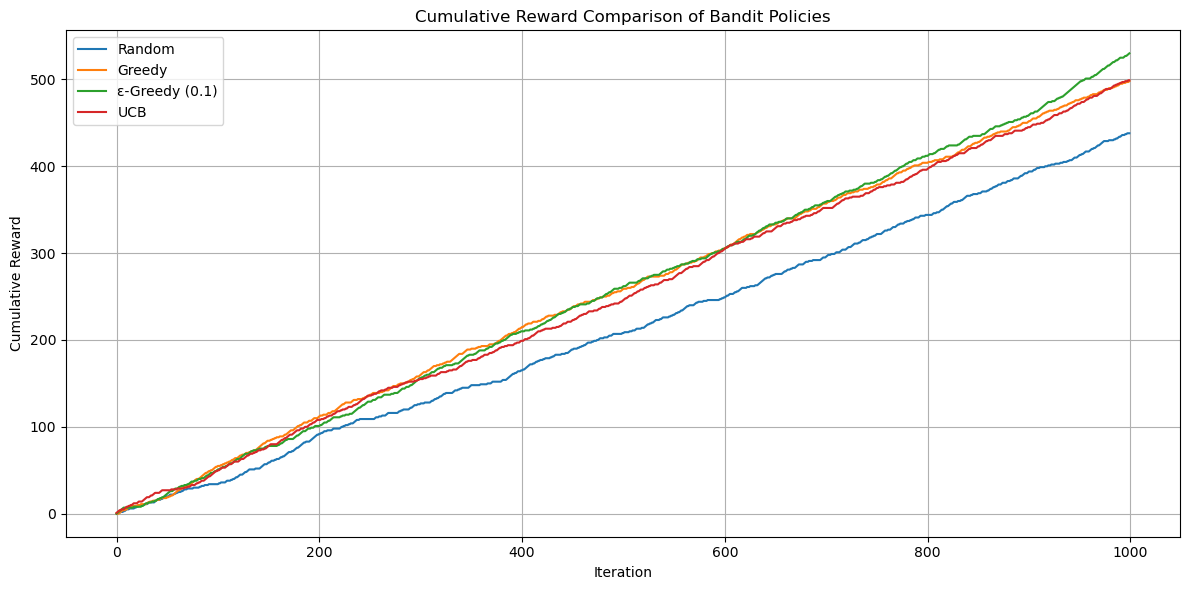

In [ ]:
#-----write your code below this line---------
# Convert reward lists to cumulative sums
cumulative_rewards = {
    'Random': np.cumsum(random_rewards),
    'Greedy': np.cumsum(greedy_rewards),
    'ε-Greedy (0.1)': np.cumsum(results[0.1][1]),
    'UCB': np.cumsum(ucb_rewards)
}

# Plot
plt.figure(figsize=(12, 6))
for policy, rewards in cumulative_rewards.items():
    plt.plot(rewards, label=policy)

plt.title("Cumulative Reward Comparison of Bandit Policies")
plt.xlabel("Iteration")
plt.ylabel("Cumulative Reward")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Conclusion

write a conclusion (approximately 250 words) summarizing which treatment policy was most effective. Discuss the balance between exploration and exploitation in your simulations.

### The Random policy was the least effective, achieving the lowest cumulative reward.

It lacked any learning mechanism and made selections without considering past outcomes, resulting in poor decision-making.

### The Greedy policy showed moderate performance, better than Random but inferior to both UCB and ε-Greedy (ε = 0.1).

It lacked exploration and quickly committed to early high-reward arms, which led to missed opportunities in discovering better treatments.

### The ε-Greedy policy with ε = 0.1 also performed well, ranking second.

It maintained a controlled level of exploration, which helped avoid premature convergence on suboptimal arms.

However, increasing ε to 0.2 or 0.5 resulted in performance degradation due to excessive exploration, which reduced cumulative rewards.

### Upper Confidence Bound (UCB) emerged as the most effective treatment selection policy, consistently achieving the highest cumulative reward over 1000 iterations.

This was due to its ability to intelligently balance exploration and exploitation, by selecting arms with high potential or limited prior data.

UCB’s strategic exploration phase early on helped identify the most effective treatments, followed by a shift to focused exploitation.

**Policies like UCB and ε-Greedy (with low ε) provide a structured approach to discovering effective treatments while maximizing patient benefit.**